# Wstępne przetwarzanie obrazów z użyciem OpenCV
W tym notatniku prezentuję podstawowe operacje na obrazach cyfrowych wykorzystywane w systemach wizyjnych. 

Projekt obejmuje wczytywanie i zarządzanie danymi, konwersję przestrzeni barw (RGB/Grayscale), analizę rozkładu jasności pikseli w przestrzeni trójwymiarowej oraz wykorzystanie map pseudokolorów (colormaps) do poprawy percepcji kontrastu.

In [1]:
import cv2
from matplotlib import pyplot as plt
import os

### Pobieranie danych i konwersja przestrzeni barw
Skrypt automatycznie pobiera obraz testowy z zewnętrznego repozytorium, upewniając się, że nie jest on pobierany wielokrotnie.

Domyślnie funkcja `imread` biblioteki OpenCV wczytuje obrazy w formacie **BGR** (Blue-Green-Red). Aby poprawnie wyświetlić obraz za pomocą biblioteki Matplotlib, dokonuję niezbędnej konwersji do standardowego formatu **RGB**.

--2026-03-18 00:15:07--  https://raw.githubusercontent.com/vision-agh/poc_sw/master/01_Intro/mandril.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77244 (75K) [image/jpeg]
Saving to: 'mandril.jpg'

     0K .......... .......... .......... .......... .......... 66%  991K 0s
    50K .......... .......... .....                           100% 9,65M=0,05s

2026-03-18 00:15:07 (1,39 MB/s) - 'mandril.jpg' saved [77244/77244]



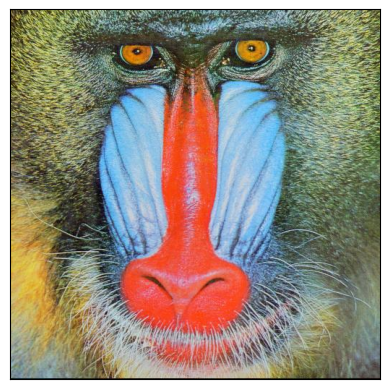

In [2]:
if not os.path.exists("mandril.jpg") :
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/01_Intro/mandril.jpg

I = cv2.imread('mandril.jpg')
I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)

plt.imshow(I)
plt.xticks([]), plt.yticks([])
plt.show()


### Konwersja do skali szarości (Grayscale)
Większość algorytmów analizy obrazu i detekcji cech operuje na obrazach jednokanałowych (w skali szarości). Pozwala to na znaczną redukcję złożoności obliczeniowej przy jednoczesnym zachowaniu kluczowych informacji o kształtach i strukturze obiektów na zdjęciu.

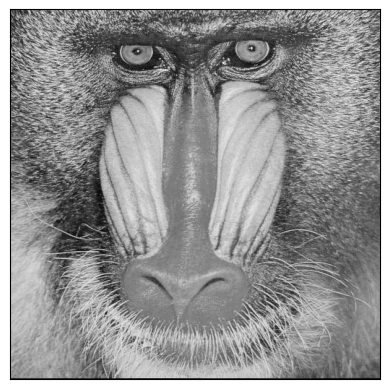

In [3]:
IG = cv2.cvtColor(I, cv2.COLOR_RGB2GRAY)
plt.imshow(IG)
plt.xticks([]), plt.yticks([])
plt.gray()
plt.show()


### Serializacja przetworzonych danych
Przetworzony obraz (po redukcji kanałów kolorów) eksportuję do formatu bezstratnego `.png` w celu jego ewentualnego późniejszego wykorzystania przez inne moduły systemu wizyjnego.

In [4]:
cv2.imwrite('mandril_gray.png', IG)

True

### Analiza obrazu jako dwuwymiarowej funkcji $L(x,y)$
Obraz cyfrowy w skali szarości można rozpatrywać jako dwuwymiarową funkcję dyskretną, gdzie $x$ i $y$ reprezentują pozycję piksela, a wartość $L(x,y)$ to jego intensywność (zwykle w przedziale $[0, 255]$).

Poniżej generuję trójwymiarową wizualizację mapy jasności wykorzystując siatkę z biblioteki NumPy. Taka reprezentacja ułatwia analizę ekstremów lokalnych i szumu.

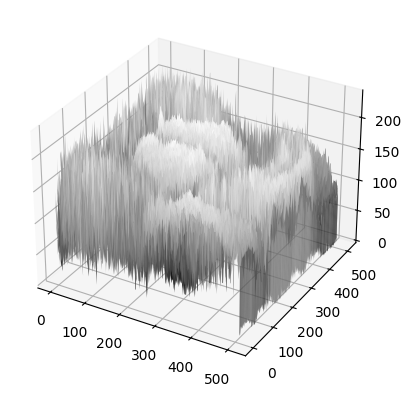

In [5]:
import numpy as np

# create grid
xx, yy = np.mgrid[0:IG.shape[0], 0:IG.shape[1]]

# create the figure
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xx, yy, IG ,rstride=3, cstride=3, cmap=plt.get_cmap('gray'),
        linewidth=0)

# show it
plt.show()

### Profile intensywności (Przekroje obrazu)
Podczas projektowania układów sterowania lub filtrów wizyjnych, przydatne jest badanie gradientów jasności. W tym kroku wyodrębniam i wizualizuję jednowymiarowe wektory jasności (przekrój przez ustalony wiersz i kolumnę macierzy obrazu).

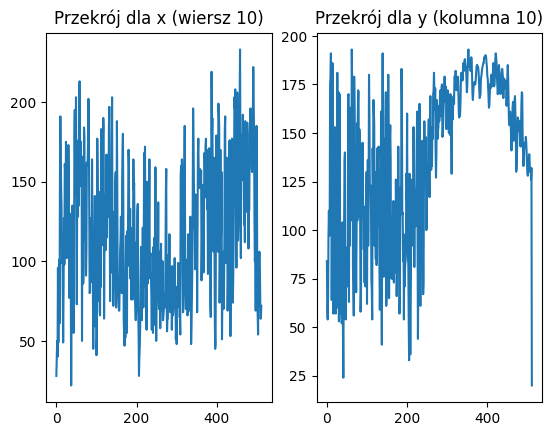

In [6]:
S = IG[10,:]
Y = IG[:,10]
f, (ax1,ax2) = plt.subplots(1,2)
ax1.set_title('Przekrój dla x (wiersz 10)')
ax1.plot(S)
ax2.set_title('Przekrój dla y (kolumna 10)')
ax2.plot(Y)
plt.show()

### Mapowanie pseudokolorów (Colormaps)
Wykorzystanie map pseudokolorów (np. map `cool`, `GnBu` czy `autumn`) to technika szeroko stosowana w analizie obrazów medycznych, termicznych czy satelitarnych. 

Chociaż nie wprowadza to nowych informacji do danych pierwotnych obrazu jednokanałowego, "kolorowanie" oparte o Look-Up Tables (LUT) znacząco poprawia percepcję subtelnych różnic w kontraście przez układ wzrokowy człowieka.

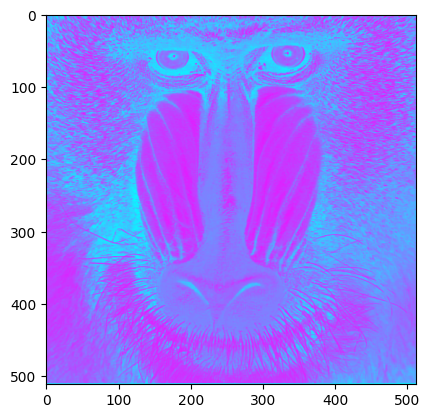

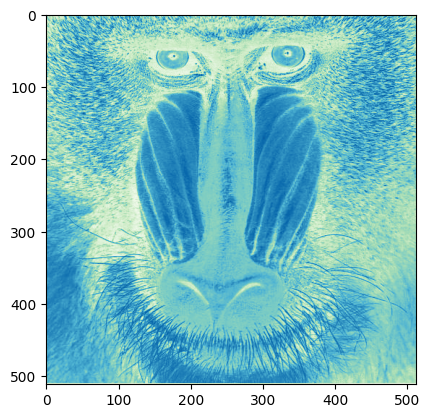

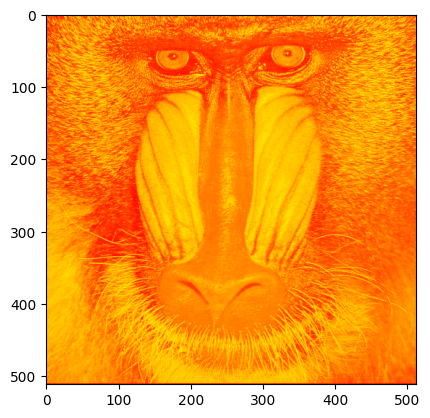

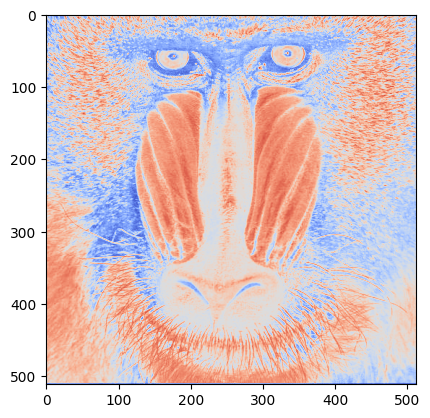

In [7]:
plt.imshow(IG, cmap=plt.get_cmap('cool'))
plt.show()

plt.imshow(IG, cmap=plt.get_cmap('GnBu'))
plt.show()

plt.imshow(IG, cmap=plt.get_cmap('autumn'))
plt.show()

plt.imshow(IG, cmap=plt.get_cmap('coolwarm'))
plt.show()